   Income  Credit_Score  Loan_Amount  Employment_Years  Approved
0   35795           538        14823                 1         0
1   20860           628        14540                 5         0
2   96820           766        21364                 5         1
3   74886           650         9611                 6         0
4   26265           797        32663                 3         0
Approved
0    129
1     71
Name: count, dtype: int64
Accuracy: 0.925
Confusion Matrix:
 [[27  0]
 [ 3 10]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95        27
           1       1.00      0.77      0.87        13

    accuracy                           0.93        40
   macro avg       0.95      0.88      0.91        40
weighted avg       0.93      0.93      0.92        40



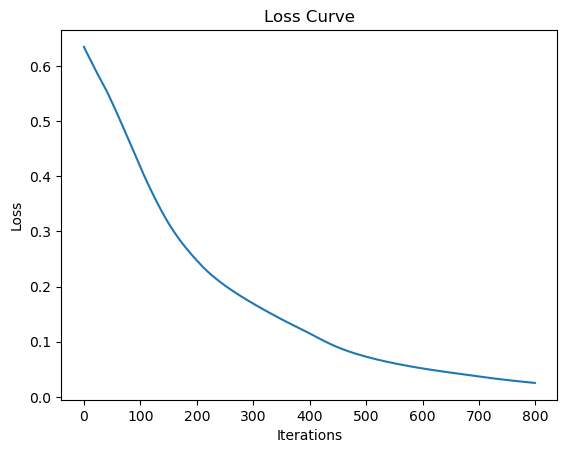

New Loan Prediction: 1


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)

n = 200

data = pd.DataFrame({
    'Income': np.random.randint(20000, 100000, n),
    'Credit_Score': np.random.randint(500, 800, n),
    'Loan_Amount': np.random.randint(5000, 40000, n),
    'Employment_Years': np.random.randint(1, 15, n)
})

data['Approved'] = (
    (data['Income'] > 40000) &
    (data['Credit_Score'] > 650)
).astype(int)

print(data.head())
print(data['Approved'].value_counts())

X = data.drop('Approved', axis=1)
y = data['Approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

plt.figure()
plt.plot(mlp.loss_curve_)
plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

new_data = pd.DataFrame([[60000, 700, 20000, 5]],
                        columns=['Income', 'Credit_Score', 'Loan_Amount', 'Employment_Years'])

new_data_scaled = scaler.transform(new_data)

prediction = mlp.predict(new_data_scaled)
print("New Loan Prediction:", prediction[0])